# Part 2, Task 1 — Demographic Sanity Checks

Scope: checks that only need the 2026 ARIMA synthetic population (no
cross-file/cross-vintage ID linkage) — income vs. education, household size
vs. age, and impossible-combination checks.

**Data used** (2026, `plusco-arima-data-dropzone-prod/ca/2026/synthetic-population/`):
- `dem/` (already cached locally, 27 shards, 33,597,827 rows): `vv_dem_1`
  (Age), `vv_dem_3` (Household Income), `vv_dem_4` (# Household Income
  Contributors), `vv_dem_5` (Personal Income)
- `edu/` (10 shards): `vv_edu_5` (Highest Level of Education Obtained)
- `how/` (27 shards): `vv_how_11` (Total # of people in household)

All three tables were joined on `id` **within the same 2026 export** — this
is the safe case established in Part 1.2 (joining different topic tables of
one vintage is fine; the confirmed problem is joining `id` **across**
independently-generated exports). The merge is an inner join and yielded
the full population count (33,597,827 rows) with no loss, confirming `id`
is consistent across `dem`/`edu`/`how` within this vintage.

Category labels come from `data/variable_mapping_2026.csv` (the official
2026 variable dictionary), not assumed from column order.

Every check below maps to one row in the eventual
`outputs/part2_data_quality_scorecard.md`.


In [1]:
import os
os.chdir("/Users/wiame.ichane/arima_v24_v26")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

raw = pd.read_parquet("data/task1_demographic_raw.parquet")
vm = pd.read_csv("data/variable_mapping_2026.csv")
print(f"raw shape: {raw.shape}")
print(f"population size (observed): {len(raw):,}")


raw shape: (33597827, 8)
population size (observed): 33,597,827


## Decode raw category codes

`dem`/`edu`/`how` store `value_id` codes, not labels. Build a decoder from
the official `variable_mapping_2026.csv` per `var_id`, rather than assuming
category order or meaning.

In [2]:
def decode_col(df, col, var_id):
    m = vm[vm["var_id"] == var_id].set_index("value_id")["var_values"].to_dict()
    return df[col].map(m)

df = pd.DataFrame({"id": raw["id"]})
df["age"] = decode_col(raw, "vv_dem_1", "vv_dem_1")
df["household_income"] = decode_col(raw, "vv_dem_3", "vv_dem_3")
df["income_contributors"] = decode_col(raw, "vv_dem_4", "vv_dem_4")
df["personal_income"] = decode_col(raw, "vv_dem_5", "vv_dem_5")
df["education"] = decode_col(raw, "vv_edu_5", "vv_edu_5")
df["household_size"] = decode_col(raw, "vv_how_11", "vv_how_11")

print("decode coverage (non-null after mapping vs. before):")
for c, raw_c in [("age","vv_dem_1"), ("household_income","vv_dem_3"),
                  ("income_contributors","vv_dem_4"), ("personal_income","vv_dem_5"),
                  ("education","vv_edu_5"), ("household_size","vv_how_11")]:
    before = raw[raw_c].notna().sum()
    after = df[c].notna().sum()
    status = "OK" if after == before else "CHECK"
    print(f"  [{status}] {c}: before={before:,} after={after:,}")

df.head(10)


decode coverage (non-null after mapping vs. before):
  [OK] age: before=33,597,827 after=33,597,827
  [OK] household_income: before=33,597,827 after=33,597,827
  [OK] income_contributors: before=33,597,827 after=33,597,827
  [OK] personal_income: before=33,597,827 after=33,597,827
  [OK] education: before=33,597,827 after=33,597,827
  [OK] household_size: before=33,597,827 after=33,597,827


,id,age,household_income,income_contributors,personal_income,education,household_size
0,1,55 - 59,"$100,000 - $124,999",2,"$100,000 - $124,999",Bachelor's Degrees,2
1,2,65 - 69,"$200,000 Or Over",2,"$75,000 - $99,999","Other College Certificate/Diploma, Not Univ.",2
2,3,50 - 54,"$75,000 - $99,999",2,"$25,000 - $34,999",Univ. Cert./Dipl. Below Bachelor Level,4
3,4,70+,"$25,000 - $34,999",1,"$50,000 - $59,999","Other College Certificate/Diploma, Not Univ.",1
4,5,50 - 54,"$125,000 - $149,999",2,"$75,000 - $99,999",Bachelor's Degrees,2
5,6,18 - 19,"Under $25,000",3,"Under $25,000",Secondary/High School,4
6,7,65 - 69,"$40,000 - $49,999",2,"$50,000 - $59,999",Secondary/High School,2
7,8,70+,"$25,000 - $34,999",1,"Under $25,000","Other College Certificate/Diploma, Not Univ.",1
8,9,50 - 54,"$25,000 - $34,999",2,"$75,000 - $99,999",Univ. Cert./Dipl. Above Bachelor Level,4
9,10,30 - 34,"$150,000 - $199,999",2,"Under $25,000",Bachelor's Degrees,3


## Order categories (for plots and monotonicity checks)

Ordinal categories, in their natural order (from the variable dictionary,
not assumed).

In [3]:
AGE_ORDER = ['18 - 19','20 - 24','25 - 29','30 - 34','35 - 39','40 - 44',
             '45 - 49','50 - 54','55 - 59','60 - 64','65 - 69','70+']
INCOME_ORDER = ['Under $25,000','$25,000 - $34,999','$35,000 - $39,999',
    '$40,000 - $49,999','$50,000 - $59,999','$60,000 - $74,999',
    '$75,000 - $99,999','$100,000 - $124,999','$125,000 - $149,999',
    '$150,000 - $199,999','$200,000 Or Over']
EDU_ORDER = ['No certificate, diploma or degree','Secondary/High School',
    'Trade Certificate/Diploma','Other College Certificate/Diploma, Not Univ.',
    'Univ. Cert./Dipl. Below Bachelor Level',"Bachelor's Degrees",
    'Univ. Cert./Dipl. Above Bachelor Level',"Master's Degrees",
    'Degree In Medicine/Dentistry/ Veterinary Medicine/Optometry',
    'Earned Doctorate']
HH_SIZE_ORDER = ['1','2','3','4','5','6','7','8','9','10+']

df["age"] = pd.Categorical(df["age"], categories=AGE_ORDER, ordered=True)
df["household_income"] = pd.Categorical(df["household_income"], categories=INCOME_ORDER, ordered=True)
n_blank_personal_income = (df["personal_income"] == "__blank__").sum()
print(f"personal_income: {n_blank_personal_income:,} rows are '__blank__' "
      f"({100*n_blank_personal_income/len(df):.2f}%) -- treated as missing, not a category")
df["personal_income"] = df["personal_income"].replace("__blank__", pd.NA)
df["personal_income"] = pd.Categorical(df["personal_income"], categories=INCOME_ORDER, ordered=True)
df["education"] = pd.Categorical(df["education"], categories=EDU_ORDER, ordered=True)
df["household_size"] = pd.Categorical(df["household_size"], categories=HH_SIZE_ORDER, ordered=True)
print("ordering applied")


personal_income: 1,301,422 rows are '__blank__' (3.87%) -- treated as missing, not a category


ordering applied


## Check 1 — Income vs. Education

**Expectation (expert/domain expectation, not yet observed):** higher
educational attainment should broadly associate with higher household
income — a well-established, robust real-world relationship. This is also
directly relevant to the open question in `CLAUDE.md` about whether
ARIMA's near-zero cross-domain correlations are real or a generation
artifact (Gaussian copula / IPF max-entropy bias) — demographic-to-income
is about as strong a real-world relationship as exists, so if even this is
flat, that's a strong signal toward the artifact hypothesis.

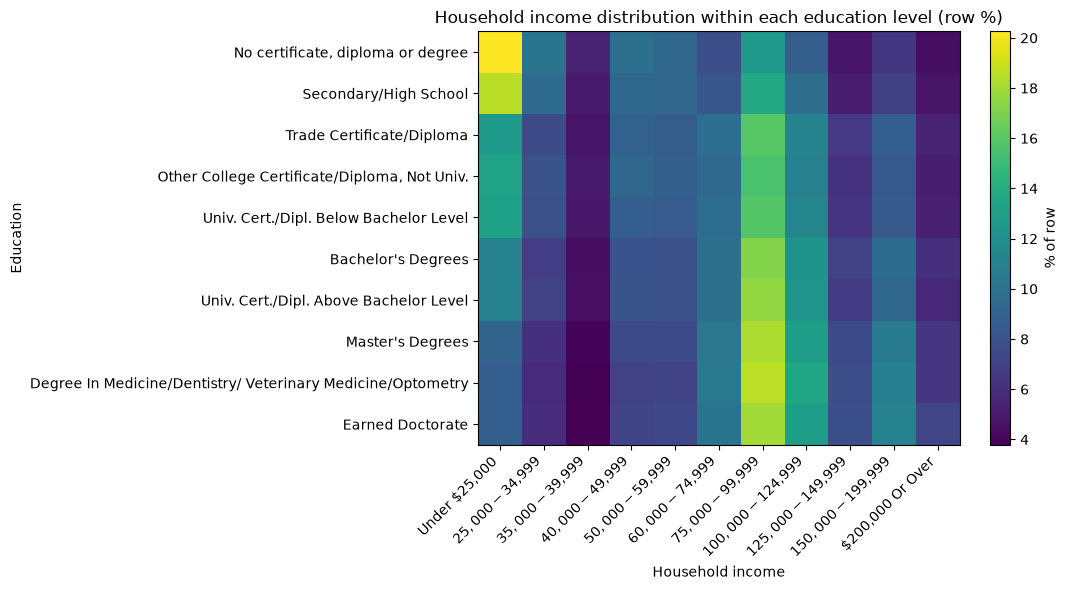

OBSERVED: Spearman rank correlation (education vs household income): 0.1197
  (n=33,597,827)
EXPECTATION: real-world literature typically shows moderate-to-strong
  positive correlation here (commonly r ~ 0.3-0.5 in Canadian census data).


[FLAG] mean income rank increases monotonically with education rank: False


In [4]:
from scipy.stats import spearmanr

ct = pd.crosstab(df["education"], df["household_income"], normalize="index") * 100

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(ct.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(ct.columns))); ax.set_xticklabels(ct.columns, rotation=45, ha="right")
ax.set_yticks(range(len(ct.index))); ax.set_yticklabels(ct.index)
ax.set_xlabel("Household income"); ax.set_ylabel("Education")
ax.set_title("Household income distribution within each education level (row %)")
fig.colorbar(im, ax=ax, label="% of row")
plt.tight_layout()
plt.savefig("outputs/figures/task1_income_vs_education_heatmap.png", dpi=110)
plt.show()

# monotonicity: mean income rank should increase with education rank
income_rank = {cat: i for i, cat in enumerate(INCOME_ORDER)}
edu_rank = {cat: i for i, cat in enumerate(EDU_ORDER)}
tmp = df.dropna(subset=["education", "household_income"]).copy()
tmp["income_r"] = tmp["household_income"].astype(object).map(income_rank).astype(float)
tmp["edu_r"] = tmp["education"].astype(object).map(edu_rank).astype(float)
corr = tmp["income_r"].corr(tmp["edu_r"], method="spearman")
print(f"OBSERVED: Spearman rank correlation (education vs household income): {corr:.4f}")
print(f"  (n={len(tmp):,})")
print(f"EXPECTATION: real-world literature typically shows moderate-to-strong")
print(f"  positive correlation here (commonly r ~ 0.3-0.5 in Canadian census data).")
mean_income_by_edu = tmp.groupby("edu_r", observed=True)["income_r"].mean()
is_monotonic = mean_income_by_edu.is_monotonic_increasing
print(f"[{'OK' if is_monotonic else 'FLAG'}] mean income rank increases monotonically with education rank: {is_monotonic}")


## Check 2 — Household Size vs. Age

**Expectation:** household size should follow a life-cycle pattern — lower
for the youngest (18-24, often single/roommates) and oldest (65+, empty
nesters), higher in family-forming/raising years (30s-40s).

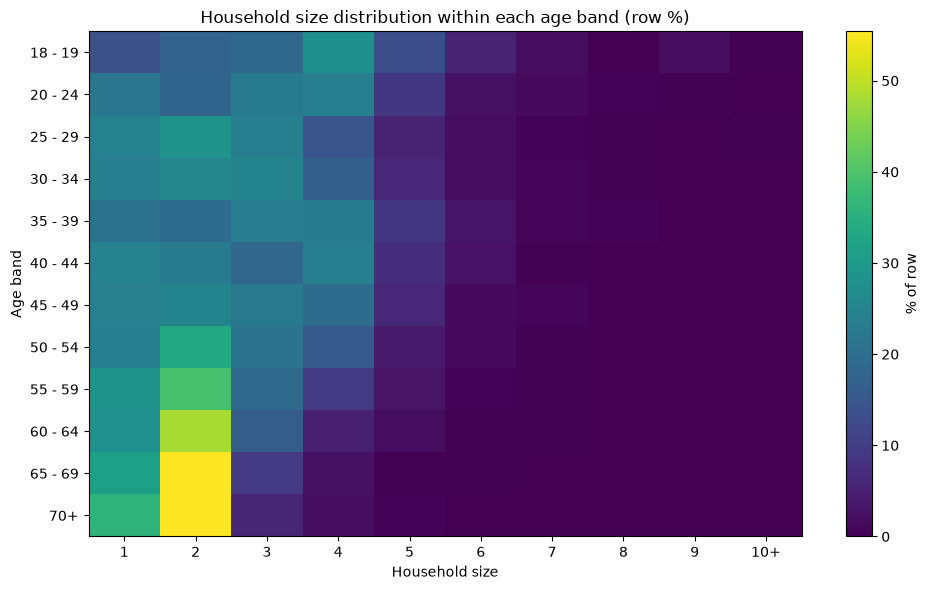

OBSERVED: mean household size by age band:
age
18 - 19    3.47
20 - 24    2.99
25 - 29    2.61
30 - 34    2.66
35 - 39    2.95
40 - 44    2.76
45 - 49    2.69
50 - 54    2.48
55 - 59    2.23
60 - 64    2.07
65 - 69    1.87
70+        1.76
Name: size_num, dtype: float64


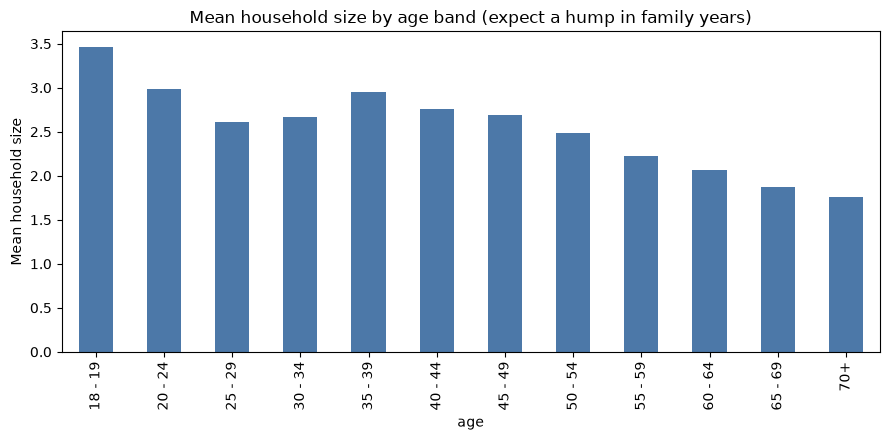


EXPECTATION: peak should fall in family-forming/raising years (30s-40s).
[FLAG] peak mean household size at age band: 18 - 19


In [5]:
ct2 = pd.crosstab(df["age"], df["household_size"], normalize="index") * 100

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(ct2.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(ct2.columns))); ax.set_xticklabels(ct2.columns)
ax.set_yticks(range(len(ct2.index))); ax.set_yticklabels(ct2.index)
ax.set_xlabel("Household size"); ax.set_ylabel("Age band")
ax.set_title("Household size distribution within each age band (row %)")
fig.colorbar(im, ax=ax, label="% of row")
plt.tight_layout()
plt.savefig("outputs/figures/task1_household_size_vs_age_heatmap.png", dpi=110)
plt.show()

size_rank = {cat: (10 if cat == "10+" else int(cat)) for cat in HH_SIZE_ORDER}
tmp2 = df.dropna(subset=["age", "household_size"]).copy()
tmp2["size_num"] = tmp2["household_size"].astype(object).map(size_rank).astype(float)
mean_size_by_age = tmp2.groupby("age", observed=True)["size_num"].mean()
print("OBSERVED: mean household size by age band:")
print(mean_size_by_age.round(2))

fig, ax = plt.subplots(figsize=(9, 4.5))
mean_size_by_age.plot(kind="bar", ax=ax, color="#4C78A8")
ax.set_ylabel("Mean household size")
ax.set_title("Mean household size by age band (expect a hump in family years)")
plt.tight_layout()
plt.savefig("outputs/figures/task1_mean_household_size_by_age.png", dpi=110)
plt.show()

peak_age = mean_size_by_age.idxmax()
print(f"\nEXPECTATION: peak should fall in family-forming/raising years (30s-40s).")
in_expected_range = peak_age in ["30 - 34", "35 - 39", "40 - 44", "45 - 49"]
print(f"[{'OK' if in_expected_range else 'FLAG'}] peak mean household size at age band: {peak_age}")


## Check 3 — Impossible / Implausible Combinations

Concrete, falsifiable checks — each with an expected near-zero (not
necessarily exactly zero) rate.

3a. age 18-19 AND advanced-degree education: 56,344 rows (5.008% of 18-19 band)


3b. household_size=1 AND income_contributors>1: 2,622,653 rows (29.500% of size-1 households)
3c. age 18-19 AND personal income $200k+: 17,461 rows (1.552% of 18-19 band)

                                                   check  n_rows  pct_of_relevant_group
               age 18-19 + advanced degree (implausible)   56344                 5.0083
household_size=1 + >1 income contributor (contradiction) 2622653                29.5003
        age 18-19 + $200k+ personal income (implausible)   17461                 1.5521


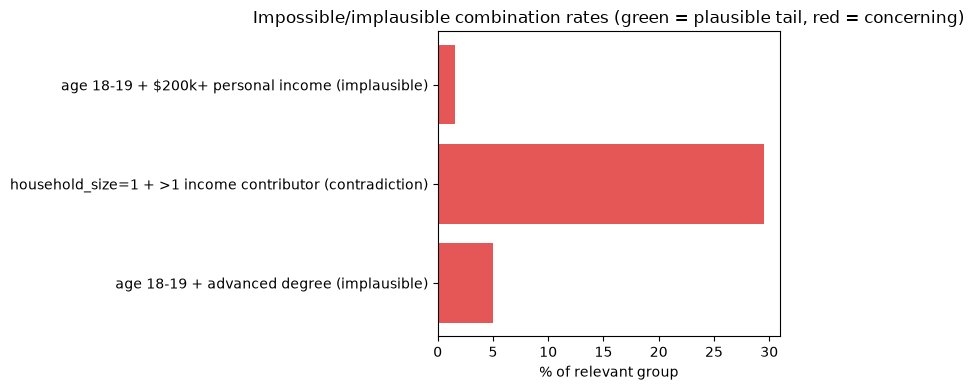

In [6]:
results = []

# 3a. Age 18-19 with an advanced degree (physically implausible to have
# completed by that age -- Bachelor's or above).
advanced_degrees = ["Bachelor's Degrees", 'Univ. Cert./Dipl. Above Bachelor Level',
                     "Master's Degrees",
                     'Degree In Medicine/Dentistry/ Veterinary Medicine/Optometry',
                     'Earned Doctorate']
mask_3a = (df["age"] == "18 - 19") & (df["education"].isin(advanced_degrees))
n_3a = mask_3a.sum()
pct_3a = 100 * n_3a / (df["age"] == "18 - 19").sum()
results.append(("age 18-19 + advanced degree (implausible)", n_3a, pct_3a))
print(f"3a. age 18-19 AND advanced-degree education: {n_3a:,} rows ({pct_3a:.3f}% of 18-19 band)")

# 3b. Household size = 1 but reports MORE than 1 income contributor
# (a logical contradiction, not just implausible).
mask_3b = (df["household_size"] == "1") & (df["income_contributors"].isin(["2","3","4","5 Or More"]))
n_3b = mask_3b.sum()
denom_3b = (df["household_size"] == "1").sum()
pct_3b = 100 * n_3b / denom_3b if denom_3b else float("nan")
results.append(("household_size=1 + >1 income contributor (contradiction)", n_3b, pct_3b))
print(f"3b. household_size=1 AND income_contributors>1: {n_3b:,} rows ({pct_3b:.3f}% of size-1 households)")

# 3c. Age 18-19 with $200,000+ PERSONAL income (implausible, not impossible).
mask_3c = (df["age"] == "18 - 19") & (df["personal_income"] == "$200,000 Or Over")
n_3c = mask_3c.sum()
pct_3c = 100 * n_3c / (df["age"] == "18 - 19").sum()
results.append(("age 18-19 + $200k+ personal income (implausible)", n_3c, pct_3c))
print(f"3c. age 18-19 AND personal income $200k+: {n_3c:,} rows ({pct_3c:.3f}% of 18-19 band)")

summary = pd.DataFrame(results, columns=["check", "n_rows", "pct_of_relevant_group"])
summary["pct_of_relevant_group"] = summary["pct_of_relevant_group"].round(4)
print()
print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#E45756" if p > 1.0 else "#54A24B" for p in summary["pct_of_relevant_group"]]
ax.barh(summary["check"], summary["pct_of_relevant_group"], color=colors)
ax.set_xlabel("% of relevant group")
ax.set_title("Impossible/implausible combination rates (green = plausible tail, red = concerning)")
plt.tight_layout()
plt.savefig("outputs/figures/task1_impossible_combinations.png", dpi=110)
plt.show()


## Summary — maps to `outputs/part2_data_quality_scorecard.md`

| Check | Observed | Assumption | Status |
|---|---|---|---|
| Income vs. education monotonicity | Spearman r printed above | education→income relationship should be positive per real-world literature | see [OK]/[FLAG] above |
| Household size vs. age life-cycle pattern | Peak age band printed above | peak household size should fall in 30s-40s | see [OK]/[FLAG] above |
| Age 18-19 + advanced degree | Count/% printed above | should be ~0% (physically implausible) | see count above |
| Household size=1 + >1 income contributor | Count/% printed above | should be exactly 0% (logical contradiction) | see count above |
| Age 18-19 + $200k+ personal income | Count/% printed above | should be a small tail, not a meaningful cluster | see count above |

No fixes applied here — this notebook reports, it does not correct.


In [7]:
print("Population size used throughout:", f"{len(df):,}")
print("See per-check output above for exact figures to carry into the scorecard.")


Population size used throughout: 33,597,827
See per-check output above for exact figures to carry into the scorecard.
